# Charger et afficher l’image



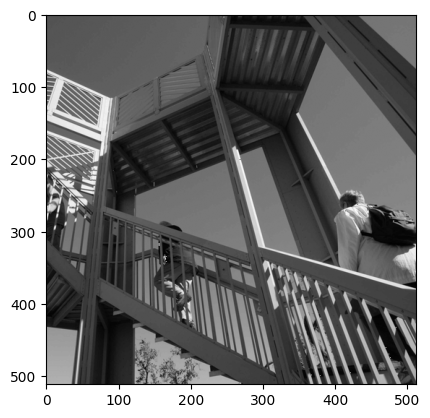

In [1]:
import cv2                # bibliothèque de traitement d'image
import numpy as np        # calcul numérique (tableaux)
from scipy import datasets  # images intégrées

# Charger l’image "ascent"
i = datasets.ascent()

import matplotlib.pyplot as plt

plt.gray()          # afficher en niveaux de gris
plt.grid(False)     # enlever la grille
plt.imshow(i)       # afficher l’image
plt.show()

On charge l’image sous forme de matrice de pixels afin de pouvoir la traiter et l’afficher.

# Préparer la convolution

In [2]:
# Copier l’image (pour ne pas modifier l’originale)
i_transformed = np.copy(i)

# Récupérer les dimensions de l’image
size_x = i.shape[0]
size_y = i.shape[1]

On récupère les dimensions de l’image et on crée une matrice pour stocker le résultat

# Définir un filtre (convolution)

In [3]:
filtre = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]]
# Encore quelques filtres à essayer pour le plaisir!
#filtre = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
#filtre = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
poids = 3

Un filtre est une petite matrice (souvent 3×3) qui permet de détecter certaines caractéristiques dans l’image.



# Appliquer la convolution

In [4]:
for x in range(1, size_x-1):
    for y in range(1, size_y-1):
        out = 0.0

        # multiplication des voisins par le filtre
        out += float(i[x-1, y-1]) * filtre[0][0]
        out += float(i[x,   y-1]) * filtre[0][1]
        out += float(i[x+1, y-1]) * filtre[0][2]
        out += float(i[x-1, y])   * filtre[1][0]
        out += float(i[x,   y])   * filtre[1][1]
        out += float(i[x+1, y])   * filtre[1][2]
        out += float(i[x-1, y+1]) * filtre[2][0]
        out += float(i[x,   y+1]) * filtre[2][1]
        out += float(i[x+1, y+1]) * filtre[2][2]

        # appliquer le poids
        out = out * poids

        # limiter entre 0 et 255
        if out < 0:
            out = 0
        if out > 255:
            out = 255

        # stocker le résultat
        i_transformed[x, y] = int(out)

On parcourt l’image, on applique le filtre sur chaque zone, puis on calcule une nouvelle valeur pour chaque pixel.

# Afficher l’image transformée

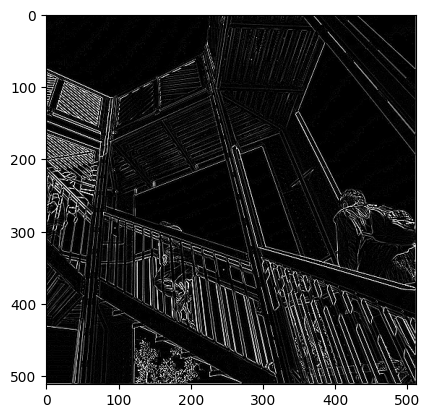

In [5]:
plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
plt.show()

On affiche le résultat après convolution
Les contours / lignes deviennent visibles

# Pooling (réduction d’image)

1. Définir la nouvelle taille devisée par 2

In [6]:
new_x = int(size_x/2)
new_y = int(size_y/2)

On ajuste les valeurs obtenues pour qu’elles restent dans un intervalle valide (0 à 255).

2. Créer une nouvelle image vide

In [7]:
newImage = np.zeros((new_x, new_y))

On crée une nouvelle matrice remplie de 0
Cette matrice va contenir l’image réduite
Taille = (new_x, new_y)

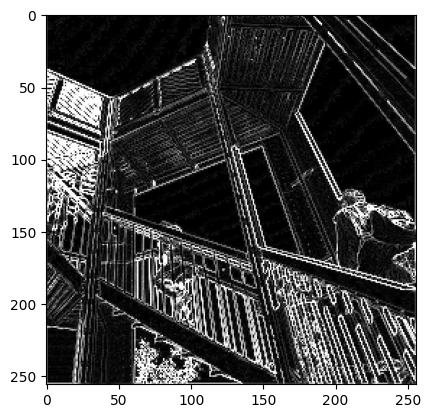

In [8]:
# Parcourir l’image avec un pas de 2 (bloc 2x2)
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):

        # Créer une liste pour stocker les 4 pixels du bloc
        pixels = []

        # Ajouter les 4 pixels du bloc 2x2
        pixels.append(i_transformed[x, y])       # pixel en haut à gauche
        pixels.append(i_transformed[x+1, y])     # pixel en bas à gauche
        pixels.append(i_transformed[x, y+1])     # pixel en haut à droite
        pixels.append(i_transformed[x+1, y+1])   # pixel en bas à droite

        # Trier les pixels du plus grand au plus petit
        pixels.sort(reverse=True)

        # Prendre la valeur maximale (premier élément)
        max_value = pixels[0]

        # Stocker cette valeur dans la nouvelle image (réduite)
        newImage[int(x/2), int(y/2)] = max_value


# Affichage de l’image après pooling
plt.gray()          # affichage en niveaux de gris
plt.grid(False)     # supprimer la grille
plt.imshow(newImage)  # afficher l’image réduite
plt.show()

Le pooling réduit la taille de l’image tout en gardant les informations importantes.